In [ ]:
# ASSIGNMENT 1

In [ ]:
# Exercise 3.1 - 3.2 - 3.3

In [3]:
import sys
print(sys.path)

['C:\\Users\\lenovo\\OneDrive - Politecnico di Milano\\Work_cloud\\DOTTORATO\\Robust Optimization', 'C:\\ModelonImpact-1.8.1\\oct-dist\\install\\Python', 'C:\\Users\\lenovo\\OneDrive - Politecnico di Milano\\Work_cloud\\DOTTORATO\\Robust Optimization', 'C:\\ModelonImpact-1.8.1\\oct-dist\\Python37\\python37.zip', 'C:\\ModelonImpact-1.8.1\\oct-dist\\Python37\\DLLs', 'C:\\ModelonImpact-1.8.1\\oct-dist\\Python37\\lib', 'C:\\ModelonImpact-1.8.1\\oct-dist\\Python37', 'C:\\ModelonImpact-1.8.1\\oct-dist\\myEnv', '', 'C:\\ModelonImpact-1.8.1\\oct-dist\\myEnv\\lib\\site-packages', 'C:\\ModelonImpact-1.8.1\\oct-dist\\myEnv\\lib\\site-packages\\win32', 'C:\\ModelonImpact-1.8.1\\oct-dist\\myEnv\\lib\\site-packages\\win32\\lib', 'C:\\ModelonImpact-1.8.1\\oct-dist\\myEnv\\lib\\site-packages\\Pythonwin', 'C:\\ModelonImpact-1.8.1\\oct-dist\\myEnv\\lib\\site-packages\\IPython\\extensions', 'C:\\Users\\lenovo\\.ipython']


In [4]:
# Add a new path to sys.path
new_path = 'C:\\ModelonImpact-1.8.1\\oct-dist\\Python37\\Lib\\site-packages'
sys.path.append(new_path)

In [5]:
import rsome as rso
import numpy as np
from rsome import ro
from rsome import msk_solver as my_solver  #Import Mosek solver interface
#from rsome import grb_solver as my_solver  #Import Gurobi solver interface
from scipy.io import loadmat         # load the mat file

In [13]:
x = loadmat('stockData.mat')  # load the mat file
Rs=x['stockData'][0][0]['returns'] #Rs contains the data used for calibration (2000-2009)
RsTest=x['stockDataTest'][0][0]['returns'] #Rs contains the data used for calibration (2010-2014)
(nStocks,nMonths)=Rs.shape

In [53]:
VaRProb = 0.95
VaReps = 1-VaRProb

In [15]:
mu=np.mean(Rs, axis=1)
tmp = Rs - mu.reshape(-1,1)@np.ones((1,nMonths))
tmp_max = abs(tmp).max(1)
Zs = np.diag(1/tmp_max)@tmp
P = np.diag(tmp_max)

In [108]:
covariance = np.cov(P@Zs)
covariance = np.round(covariance,2)
print(covariance)

[[ 0.01  0.    0.   -0.    0.    0.    0.    0.   -0.    0.  ]
 [ 0.    0.02  0.    0.   -0.   -0.    0.01  0.    0.    0.  ]
 [ 0.    0.    0.02  0.01  0.    0.    0.   -0.   -0.    0.  ]
 [-0.    0.    0.01  0.04 -0.   -0.    0.01 -0.   -0.   -0.  ]
 [ 0.   -0.    0.   -0.    0.01  0.   -0.   -0.    0.    0.  ]
 [ 0.   -0.    0.   -0.    0.    0.03  0.   -0.    0.    0.  ]
 [ 0.    0.01  0.    0.01 -0.    0.    0.03  0.    0.    0.01]
 [ 0.    0.   -0.   -0.   -0.   -0.    0.    0.01  0.    0.01]
 [-0.    0.   -0.   -0.    0.    0.    0.    0.    0.02  0.  ]
 [ 0.    0.    0.   -0.    0.    0.    0.01  0.01  0.    0.02]]


In [16]:
def getWCdist(m):
    # Returns a uniform distribution over the extreme points of [-1, 1]^m
    # When calling [vals,ps] = getWCdist(m)
    #    m: size of the random vector
    #    vals : m x N matrixarray of values that the distribution takes
    #    ps : array of probability associated to each value

    if (m==1):
        vals=np.array([-1, 1]).reshape(1,2)
        ps = np.array([0.5, 0.5])
    else:
        (vals0,ps0)=getWCdist(m-1)
        n=np.size(vals0,axis=1)
        v=np.concatenate((-1*np.ones(n), np.ones(n)))
        val=np.concatenate((vals0,vals0),axis=1)
        vals=np.concatenate(([v],val),axis=0)
        ps = np.concatenate((0.5*ps0, 0.5*ps0))
    return (vals, ps)

#getWCdist allows us to create a set of worst-case scenarios for returns
tmp=P@getWCdist(nStocks)[0]
WCRETURNS = mu.reshape(-1,1)@np.ones((1,tmp.shape[1]))+tmp

def testPolicyVaR(x,returns,VaReps):
    tmp = sorted(x@returns)
    VaR=-tmp[int(np.floor(VaReps*returns.shape[1]))]
    return VaR

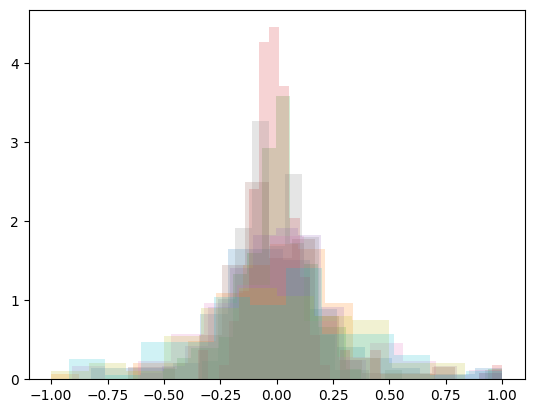

In [74]:
# Real distribution of Rs dataset (standardized to Zs)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)
for i in np.arange(10):
    ax.hist(Zs[i,:], density=True, bins='auto', histtype='stepfilled', alpha=0.2)

In [ ]:
#3.1

In [43]:
# Calibrating the ellipsoid set
tmp=np.sort(np.linalg.norm(Zs,2,axis=0))
gamma=tmp[int(np.ceil((1-VaReps)*len(tmp)))-1]
print('Calibrating the ellipsoid set: gamma={0:0.6f}'.format(gamma))

Calibrating the ellipsoid set: gamma=1.457444


In [24]:
# Calibrating the budgeted set
tmp=np.sort(np.linalg.norm(Zs,1,axis=0))
Gamma=tmp[int(np.ceil((1-VaReps)*len(tmp)))-1]
print('Calibrating the budgeted set: Gamma={0:0.6f}'.format(Gamma))

Calibrating the budgeted set: Gamma=3.606350


In [ ]:
# Calibrating the CVaR set
#theta is a vector
K = 120
model = ro.Model('find_CVaR_gamma')
theta=model.dvar(nMonths)
z = model.rvar(nStocks)
gamma_cvar = model.dvar(1)
model.min(gamma_cvar)
model.st(z.T == theta@Zs.T)
model.st(sum(theta)==1)
model.st(K*theta<=gamma_cvar)
model.st(theta>=0)
model.solve(my_solver)
obj=model.get()
xx=gamma.get() #get optimal portfolio
alpha = 1/xx
print('Calibrating the CVaR set: gamma = {0:0.6f}'.format(alpha))

In [ ]:
#3.2

In [ ]:
# Assume distrubition not from data but hp as 3.4 
#(triangular etc...symmetric and between [-1,1]...the latter is already satisfied becouse z scenario data where standardized). 

In [64]:
# Ellipsoidal set
#from scipy.stats import norm
#tmp = Zs-np.outer(Zs.mean(1),np.ones([1,Zs.shape[1]]))
#std_dev = np.std(tmp.reshape(-1))
#gamma_CC = norm.ppf(1-VaReps)*std_dev
#print('Calibrated parameter gamma should be {0:0.3f},'.format(gamma_CC),
#      'instead of {0:0.3f}'.format(gamma),',if normal distribution')
gamma_CC = (2*np.log(1/VaReps))**0.5
print('Calibrated parameter gamma should be {0:0.3f},'.format(gamma_CC),
      'instead of {0:0.3f}'.format(gamma),',if symmetric')

Calibrated parameter gamma should be 2.448, instead of 1.457 ,if symmetric


In [65]:
# Bujeted set
#tmp = Zs-np.outer(Zs.mean(1),np.ones([1,Zs.shape[1]]))
#std_dev = np.std(tmp.reshape(-1))
#Gamma_CC = norm.ppf(1-VaReps)*std_dev
#print('Calibrated parameter gamma should be {0:0.3f},'.format(Gamma_CC),
#      'instead of {0:0.3f}'.format(Gamma),',if normal distribution')
# Distributuon > no dependency on the number of scenario (m is the size of vector z (items))
Gamma_CC = (2*nStocks*np.log(1/VaReps))**0.5
print('Calibrated parameter gamma should be {0:0.3f},'.format(Gamma_CC),
      'instead of {0:0.3f}'.format(Gamma),',if symmetric')

Calibrated parameter gamma should be 7.740, instead of 3.606 ,if symmetric


In [ ]:
#3.3

In [58]:
model = ro.Model('solveRobustPortfolio_Ellipsoidal')
x=model.dvar(nStocks)
z=model.rvar(nStocks)
EllipsoidSet=(z>=-1, z<=1, rso.norm(z,2)<=gamma)
model.minmax(-(mu+P@z)@x,EllipsoidSet)
model.st(x<=1)
model.st(sum(x)==1)
model.st(x>=0)
model.solve(my_solver)
obj_Ellipsoid=model.get()
xx_Ellipsoid=x.get() #get optimal portfolio

print('Estimated VaR is {0:0.4f}'.format(obj_Ellipsoid))
print('VaR from 2000 to 2009 is {0:0.4f}'.format(testPolicyVaR(xx_Ellipsoid, Rs,VaReps)))
print('VaR from 2010 to 2014 is {0:0.4f}'.format(testPolicyVaR(xx_Ellipsoid, RsTest,VaReps)))
print('VaR with extreme distribution is {0:0.4f}'.format(testPolicyVaR(xx_Ellipsoid, WCRETURNS,VaReps)))

Being solved by Mosek...
Solution status: optimal
Running time: 0.0267s
Estimated VaR is 0.2074
VaR from 2000 to 2009 is 0.0712
VaR from 2010 to 2014 is 0.0866
VaR with extreme distribution is 0.2396


In [100]:
print(xx_Ellipsoid)

[0.17166635 0.07154632 0.03594013 0.01504179 0.11662788 0.0559843
 0.09321766 0.06224994 0.2065913  0.17113433]


In [75]:
std_extreme = np.std(WCRETURNS)
std_Rs = np.std(Rs)
std_RsTest = np.std(RsTest)
print(std_extreme)
print(std_Rs)
print(std_RsTest)

0.6823933898576231
0.14623429986614947
0.0871003936446636


In [59]:
model = ro.Model('solveRobustPortfolio_Budget')
x=model.dvar(nStocks)
z=model.rvar(nStocks)

BudgetSet=(z>=-1, z<=1, rso.norm(z,1)<=Gamma)
model.minmax(-(mu+P@z)@x,BudgetSet)
model.st(x<=1)
model.st(sum(x)==1)
model.st(x>=0)
model.solve(my_solver)
obj_Budget=model.get()
xx_Budget=x.get() #get optimal portfolio

print('Estimated VaR is {0:0.4f}'.format(obj_Budget))
print('VaR from 2000 to 2009 is {0:0.4f}'.format(testPolicyVaR(xx_Budget, Rs,VaReps)))
print('VaR from 2010 to 2014 is {0:0.4f}'.format(testPolicyVaR(xx_Budget, RsTest,VaReps)))
print('VaR with extreme distribution is {0:0.4f}'.format(testPolicyVaR(xx_Budget, WCRETURNS,VaReps)))

Being solved by Mosek...
Solution status: optimal
Running time: 0.0188s
Estimated VaR is 0.1671
VaR from 2000 to 2009 is 0.0641
VaR from 2010 to 2014 is 0.0776
VaR with extreme distribution is 0.2964


In [48]:
model = ro.Model('solveRobustPortfolio_CVaR005')
x=model.dvar(nStocks)
theta=model.rvar(nMonths)
alpha = 0.05
CVaRSet = (theta*K<=1/alpha, theta.sum()==1,theta>=0)
z = (theta@Zs.T).T

model.minmax(-(mu+P@z)@x,CVaRSet)
model.st(x<=1)
model.st(sum(x)==1)
model.st(x>=0)
model.solve(my_solver)
obj_CVaR005=model.get()
xx_CVaR005=x.get() #get optimal portfolio

print('Estimated VaR is {0:0.4f}'.format(obj_CVaR005))
print('VaR from 2000 to 2009 is {0:0.4f}'.format(testPolicyVaR(xx_CVaR005, Rs,VaReps)))
print('VaR from 2010 to 2014 is {0:0.4f}'.format(testPolicyVaR(xx_CVaR005, RsTest,VaReps)))
print('VaR with extreme distribution is {0:0.4f}'.format(testPolicyVaR(xx_CVaR005, WCRETURNS,VaReps)))

Being solved by Mosek...
Solution status: optimal
Running time: 0.0228s
Estimated VaR is 0.0556
VaR from 2000 to 2009 is 0.0497
VaR from 2010 to 2014 is 0.0661
VaR with extreme distribution is 0.3223


In [80]:
model = ro.Model('solveRobustPortfolio_Budget_CC')
x=model.dvar(nStocks)
z = model.rvar(nStocks)

BudgetSet=(z>=-1, z<=1, rso.norm(z,1)<=Gamma_CC-0.1)
model.minmax(-(mu+P@z)@x,BudgetSet)
model.st(x<=1)
model.st(sum(x)==1)
model.st(x>=0)
model.solve(my_solver)

obj_GammaAmbig=model.get()
xx_GammaAmbig=x.get() #get optimal portfolio

print('Estimated VaR is {0:0.4f}'.format(obj_GammaAmbig))
print('VaR from 2000 to 2009 is {0:0.4f}'.format(testPolicyVaR(xx_GammaAmbig, Rs,VaReps)))
print('VaR from 2010 to 2014 is {0:0.4f}'.format(testPolicyVaR(xx_GammaAmbig, RsTest,VaReps)))
print('VaR with extreme distribution is {0:0.4f}'.format(testPolicyVaR(xx_GammaAmbig, WCRETURNS,VaReps)))

Being solved by Mosek...
Solution status: optimal
Running time: 0.0280s
Estimated VaR is 0.3243
VaR from 2000 to 2009 is 0.1681
VaR from 2010 to 2014 is 0.1483
VaR with extreme distribution is 0.3243


In [88]:
model = ro.Model('solveRobustPortfolio_Ellipsoidal_CC')
x=model.dvar(nStocks)
z = model.rvar(nStocks)

EllipsoidSet=(z>=-1, z<=1, rso.norm(z,2)<=gamma_CC+5)
model.minmax(-(mu+P@z)@x,EllipsoidSet)
model.st(x<=1)
model.st(sum(x)==1)
model.st(x>=0)
model.solve(my_solver)
obj_gammaAmbig=model.get()
xx_gammaAmbig=x.get() #get optimal portfolio

print('Estimated VaR is {0:0.4f}'.format(obj_gammaAmbig))
print('VaR from 2000 to 2009 is {0:0.4f}'.format(testPolicyVaR(xx_gammaAmbig, Rs,VaReps)))
print('VaR from 2010 to 2014 is {0:0.4f}'.format(testPolicyVaR(xx_gammaAmbig, RsTest,VaReps)))
print('VaR with extreme distribution is {0:0.4f}'.format(testPolicyVaR(xx_gammaAmbig, WCRETURNS,VaReps)))

Being solved by Mosek...
Solution status: optimal
Running time: 0.0218s
Estimated VaR is 0.3243
VaR from 2000 to 2009 is 0.1681
VaR from 2010 to 2014 is 0.1483
VaR with extreme distribution is 0.3243


In [98]:
print(mu)

[0.0217989  0.028634   0.01268965 0.03458224 0.02697077 0.03426081
 0.00892307 0.02253729 0.04314391 0.03552102]


In [99]:
print(P)

[[0.38556666 0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.60606922 0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.82570452 0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         1.33817647 0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.47302476 0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.69325752
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.50831829 0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.64130146 0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.36746823 0.        ]
 [0.         0.         0.   

In [89]:
model = ro.Model('worstcase')
z=model.dvar(nStocks)

model.min((mu+P@z)@xx_gammaAmbig)
model.st(z>=-1)
model.st(z<=1)
model.st(rso.norm(z,2)<=gamma_CC+5)
model.solve(my_solver)
obj_gammaAmbig=model.get()
zz=z.get() #get optimal portfolio

print('Estimated VaR is {0:0.4f}'.format(obj_gammaAmbig))
print('VaR from 2000 to 2009 is {0:0.4f}'.format(testPolicyVaR(zz, Rs,VaReps)))
print('VaR from 2010 to 2014 is {0:0.4f}'.format(testPolicyVaR(zz, RsTest,VaReps)))
print('VaR with extreme distribution is {0:0.4f}'.format(testPolicyVaR(zz, WCRETURNS,VaReps)))
print(zz)

Being solved by Mosek...
Solution status: optimal
Running time: 0.0222s
Estimated VaR is -0.3243
VaR from 2000 to 2009 is 0.2361
VaR from 2010 to 2014 is 0.1130
VaR with extreme distribution is 0.4106
[ 0.  0.  0.  0.  0.  0.  0.  0. -1.  0.]
